In [35]:
from adcircpy import AdcircMesh, AdcircRun, Tides
from adcircpy.utilities import download_mesh, get_logger
from adcircpy.forcing.winds import BestTrackForcing
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
import pickle
import scipy.io

In [36]:
# Read in mesh
mesh = pd.read_csv("OWI_data/30k_mesh/fort14.txt", delimiter=r'\s+', header=None, usecols=[1,2],nrows=31435, names=['Lat','Lon'])


In [37]:
# Loading in fort63 data
fort63_data = scipy.io.loadmat('OWI_data/30k_mesh/fort63.mat')
fort63 = fort63_data['fort63_data']

In [43]:
def find_closest_point(df, lat, lon, fort63=None):
    """
    This function takes in the mesh, lat, and lon point and finds the closest node 
    to that lat and lon using the Haversine formula for more accurate distance calculation.

    If given a fort63 file, it will plot the elevation at that node over time.
    """
    from math import radians, sin, cos, sqrt, atan2

    def haversine_distance(lat1, lon1, lat2, lon2):
        R = 6371  # Earth's radius in kilometers

        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        
        return R * c

    # Ensure Lat and Lon columns are floats
    df['Lat'] = df['Lat'].astype(float)
    df['Lon'] = df['Lon'].astype(float)

    # Calculate the Haversine distance between the input (lat, lon) and each row in the DataFrame
    distances = df.apply(lambda row: haversine_distance(lat, lon, row['Lat'], row['Lon']), axis=1)

    # Find the index of the minimum distance
    closest_index = distances.idxmin()
    print(f'The closest index to ({lat}, {lon}) is: {closest_index}')

    if fort63 is not None:
        col_index = closest_index
        plt.figure(figsize=(10, 6))
        plt.plot(fort63[:,col_index])
        plt.title(f"Elevation at Node {col_index}")
        plt.xlabel("Time")
        plt.ylabel("Value")
        plt.grid(True)
        plt.show()
   
    return closest_index


The closest index to (24, -85) is: 3362


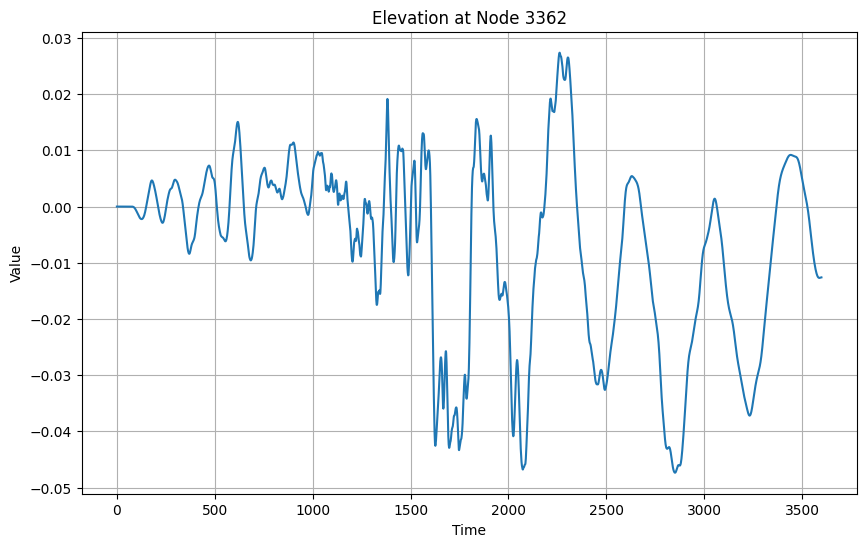

In [44]:
# Implementing above function to find closest index to desired lat and lon
lat_test = 24
lon_test = -85
test_index = find_closest_point(mesh, lat_test, lon_test, fort63)


In [33]:
#Loading in Maxeles and finding diffs

def load_maxele63(file_path, n_rows):
    """
    Reads a .txt file and returns a column of representing the max elevation at each node
    in a pandas dataframe. 
    
    Parameters:
        file_path (str): Path to the .txt file.
        
    Returns:
        pd.DataFrame: DataFrame containing the second column of numbers.
    """
    # Read the file, skip the first three rows, and select only the second column
    df = pd.read_csv(file_path, delimiter=r'\s+', skiprows=3, header=None, usecols=[1],nrows=n_rows)
    
    return df

OWI_maxele = load_maxele63("OWI_data/30k_mesh/OWI_maxele63.txt", n_rows = 31435) 
HOL_maxele = load_maxele63("Holland_data/HOL_maxele63.txt", n_rows = 31435)

# indices_to_remove = [9520, 25688, 25690, 25692] # where 9.999 are
# mesh = mesh.drop(indices_to_remove)
# HOL_maxele = HOL_maxele.drop(indices_to_remove)
# OWI_maxele = OWI_maxele.drop(indices_to_remove)

difference = OWI_maxele - HOL_maxele
df_sorted = difference.sort_values(by=difference.columns[0], ascending=True)
df_filtered = df_sorted[df_sorted.iloc[:, 0].abs() <= 9999]
print(df_filtered)

# also drop these values on the mesh

              1
7520  -4.911695
7519  -4.813655
7521  -4.015453
7149  -3.827832
7522  -3.770939
...         ...
9494   1.252091
24303  1.288389
24691  1.355097
24692  1.412578
7525   1.564323

[31428 rows x 1 columns]


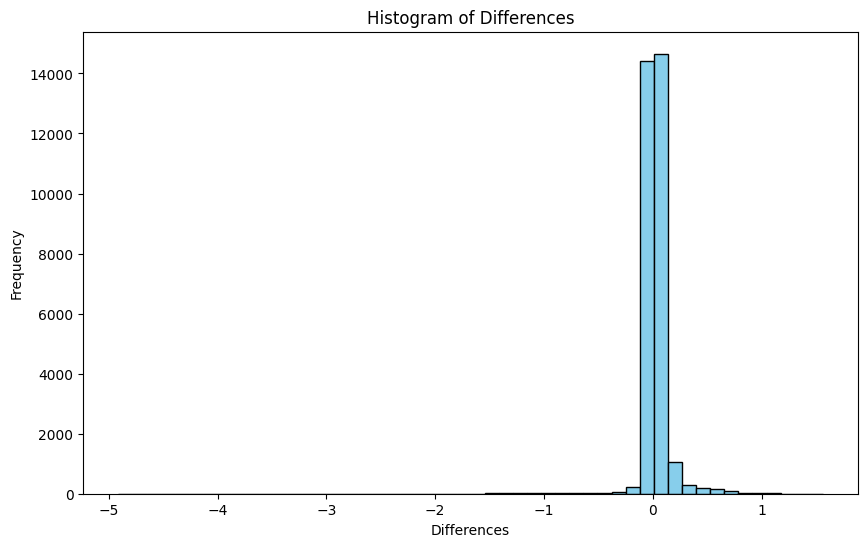

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_filtered, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Differences')
plt.ylabel('Frequency')
plt.title('Histogram of Differences')
plt.show()



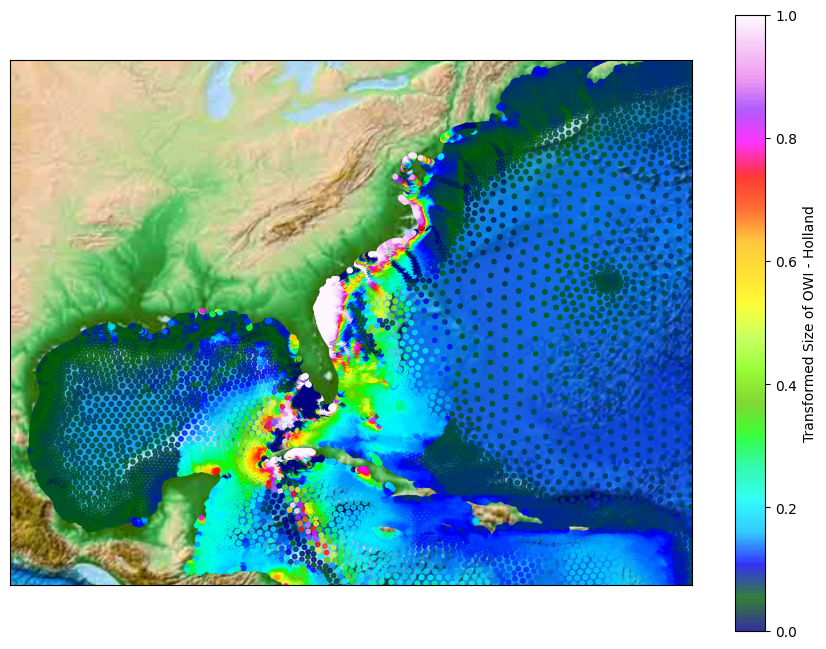

In [ ]:
plt.figure(figsize=(11, 8))
m = Basemap(llcrnrlon=-99, llcrnrlat=15, urcrnrlon=-60, urcrnrlat=45)
m.etopo()
# m.drawmapboundary(fill_color='aqua')
# m.fillcontinents(color='coral', lake_color='aqua')
scatter = m.scatter(mesh_cleaned.iloc[:,0], mesh_cleaned.iloc[:,1], c=normalized_diffs, cmap='gist_ncar', s=10, 
                      alpha = 0.8)
cbar = plt.colorbar(scatter)
# contour = m.contourf(mesh_cleaned.iloc[:,0], mesh_cleaned.iloc[:,1], normalized_diffs, cmap='gist_ncar', alpha = 0.8)
# cbar = m.colorbar(contour)
cbar.set_label('Transformed Size of OWI - Holland')

# lons = mesh_cleaned.iloc[:,0].values
# lats = mesh_cleaned.iloc[:,1].values
# values = normalized_diffs.values

# print(lats)
# grid_lons, grid_lats = np.mgrid[-99:-60:100j, 15:45:100j]

# grid_values = griddata((lons, lats), values, (grid_lons, grid_lats), method='cubic')
# contour = plt.contourf(grid_lons, grid_lats, grid_values, cmap='viridis', alpha=0.5)


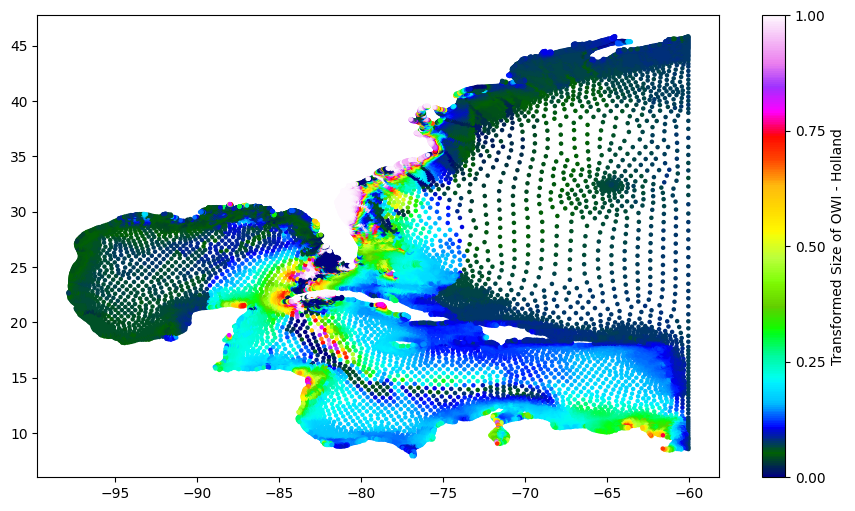

In [ ]:
plt.figure(figsize=(11, 8))
scatter = plt.scatter(mesh_cleaned.iloc[:,0], mesh_cleaned.iloc[:,1], c=normalized_diffs, cmap='gist_ncar', s=5, 
                      alpha = 1)
# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Transformed Size of OWI - Holland')

# Optional: Customize color bar ticks
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

In [ ]:
# create a tidal forcing object, using all constituents
tidal_forcing = Tides()
tidal_forcing.use_all()

# create a wind forcing object for Hurricane Sandy (2012)
wind_forcing = BestTrackForcing('Ian')

In [ ]:
DATA_DIRECTORY = Path().parent.absolute() / 'data'
INPUT_DIRECTORY = DATA_DIRECTORY / 'inputs'
MESH_DIRECTORY = INPUT_DIRECTORY / 'meshes'
OUTPUT_DIRECTORY = DATA_DIRECTORY / 'outputs'

In [ ]:
with open(MESH_DIRECTORY/"8kfort14.txt") as f:
    mesh = pd.DataFrame([line.strip().split() for line in f.readlines()],
    columns = ['Node', 'Lat', 'Lon', 'Depth'])

mesh.loc[0:8005, 'Lat':'Depth']


,Lat,Lon,Depth
0,-0.85841966E+02,0.30160585E+02,15.00
1,-0.85854895E+02,0.30119577E+02,22.00
2,-0.85812800E+02,0.30146673E+02,14.00
3,-0.85895530E+02,0.30140077E+02,22.00
4,-0.85877060E+02,0.30179229E+02,15.00
...,...,...,...
8001,-0.94478308E+02,0.29562531E+02,1.00
8002,-0.95052320E+02,0.29700093E+02,1.00
8003,-0.95061591E+02,0.29706424E+02,1.00
8004,-0.95062431E+02,0.29715203E+02,1.00


In [ ]:
# Specify the directory containing the .txt files
mannings_n_directory = OUTPUT_DIRECTORY/"mannings_n_maxele_IAN"

# Initialize an empty DataFrame
mannings_n_samples = pd.DataFrame()

# Loop through all files in the directory
for filename in os.listdir(mannings_n_directory):
    if filename.endswith(".txt"):
        # Read the specified rows and the second column (index 1) from each .txt file
        file_path = os.path.join(mannings_n_directory, filename)
        data = pd.read_csv(file_path, header=None, skiprows=3, nrows=8006, sep="\s+", usecols=[1])
        
        # Convert the single-column DataFrame to a Series
        data = data.squeeze()

        # Use the filename (without extension) as the column name
        col_name = os.path.splitext(filename)[0]
        mannings_n_samples[col_name] = data

# Save the combined DataFrame to a new CSV file if needed
mannings_n_samples



<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zr/21_jtts96kjfrxq47r_m6v7r0000gq/T/ipykernel_52838/1376432786.py:12: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(file_path, header=None, skiprows=3, nrows=8006, sep="\s+", usecols=[1])


,maxele_.003918,maxele_.002740,maxele_.016532,maxele_.016876,maxele_.004806,maxele_.001000,maxele_.015672,maxele_.002450,maxele_.015500,maxele_.017048,...,maxele_.016016,maxele_.004214,maxele_.016360,maxele_.003326,maxele_.016704,maxele_.017220,maxele_.004510,maxele_.001290,maxele_.002160,maxele_.001870
0,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,...,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646,0.527646
1,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,...,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446,0.527446
2,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,...,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797,0.527797
3,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,...,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277,0.527277
4,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,...,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510,0.527510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8001,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,...,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155,0.135155
8002,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,...,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566,0.124566
8003,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,...,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752,0.124752
8004,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,...,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781,0.124781


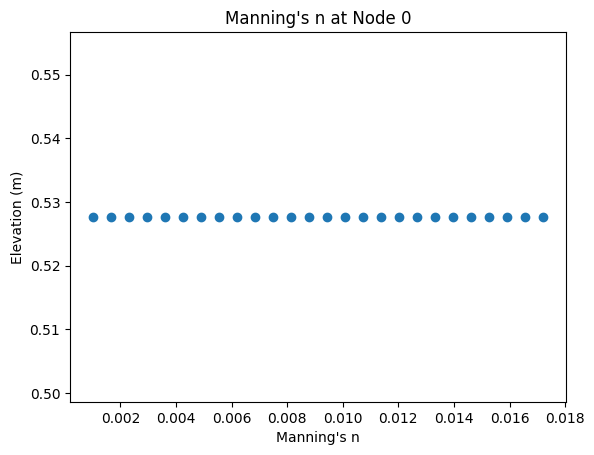

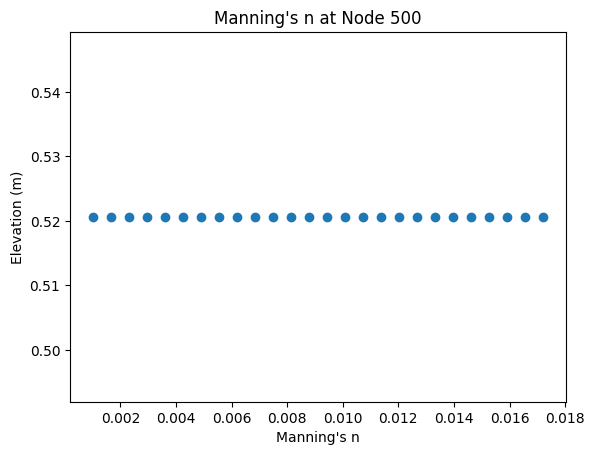

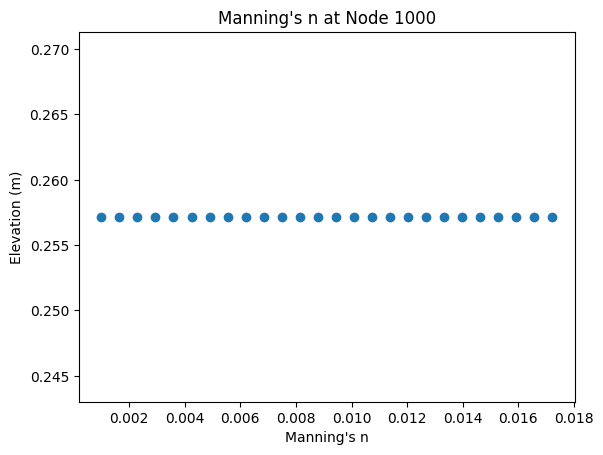

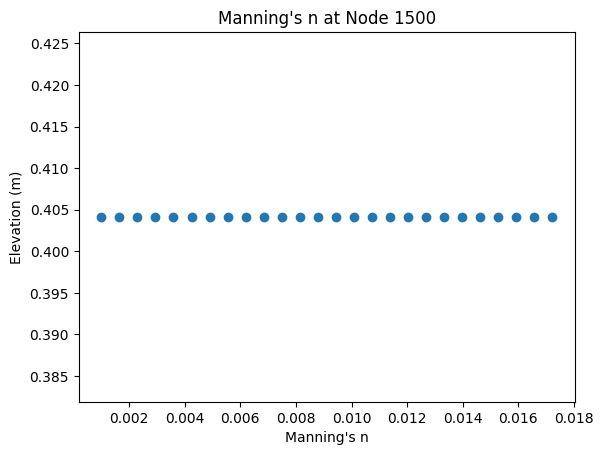

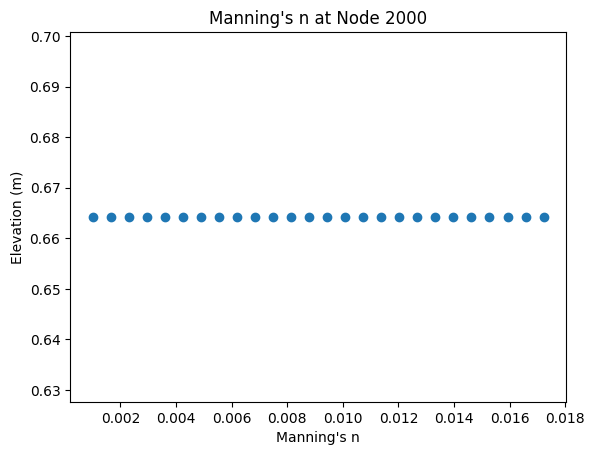

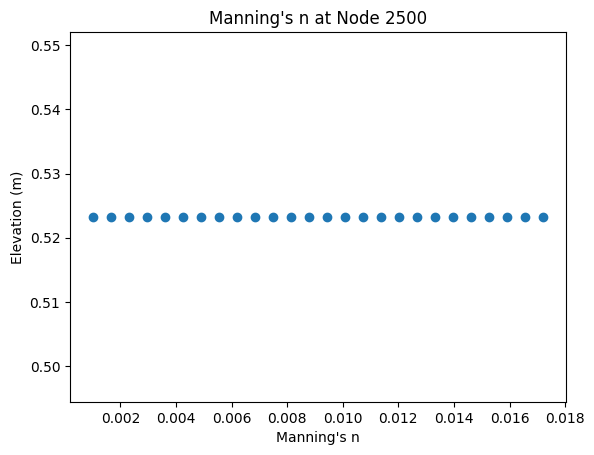

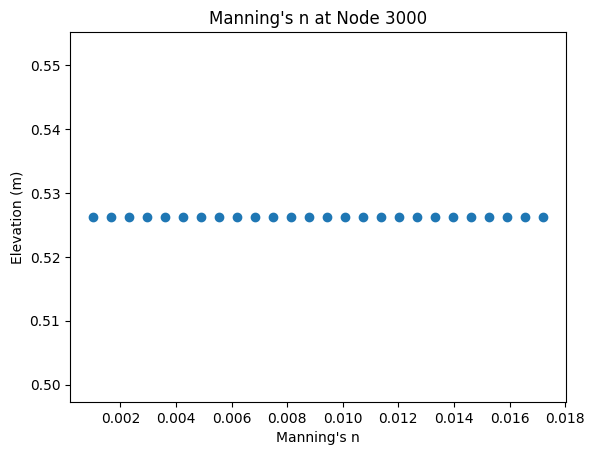

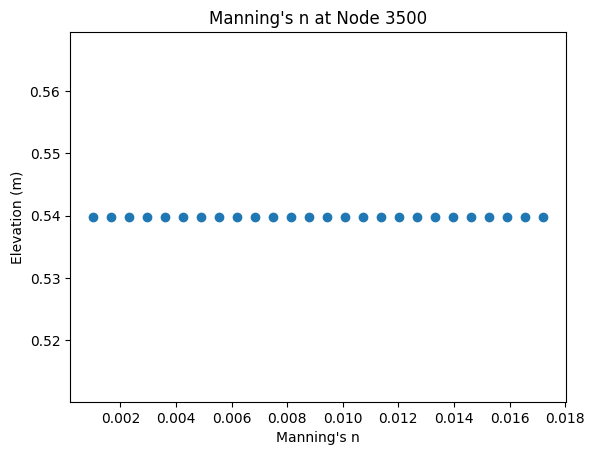

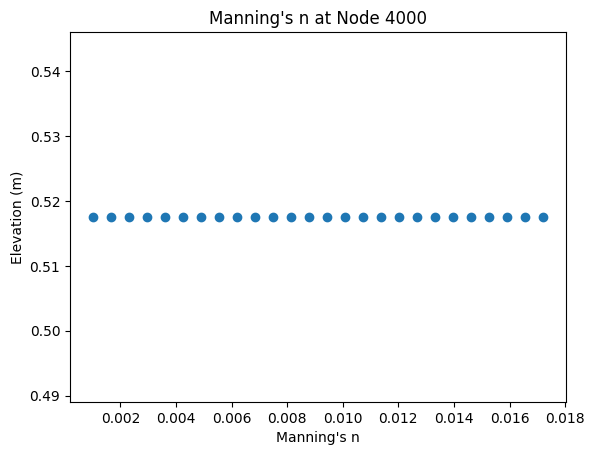

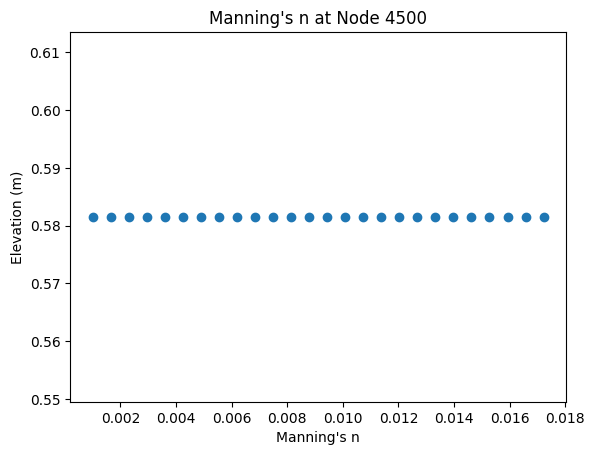

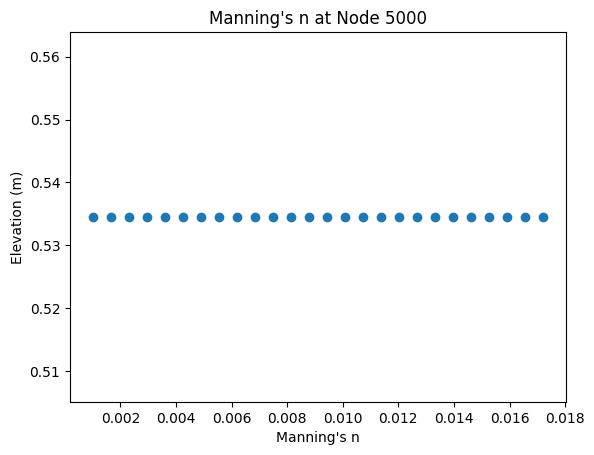

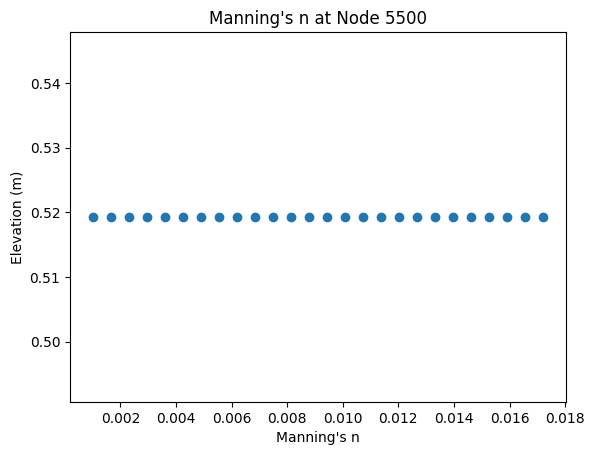

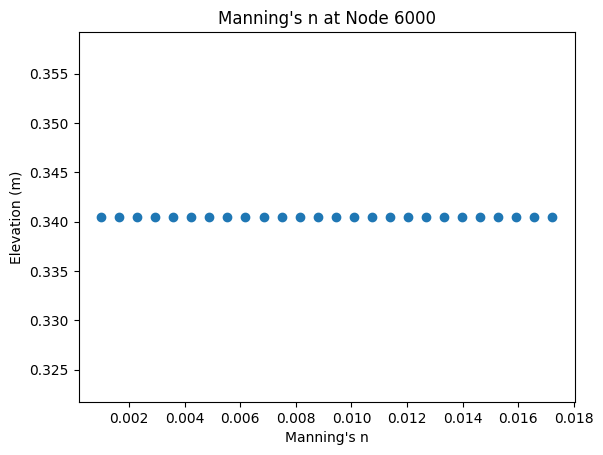

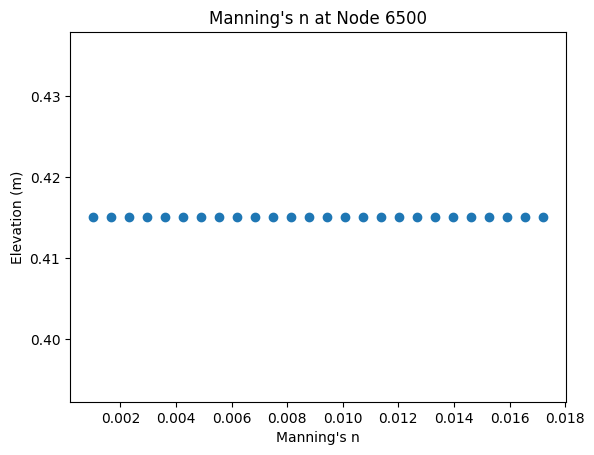

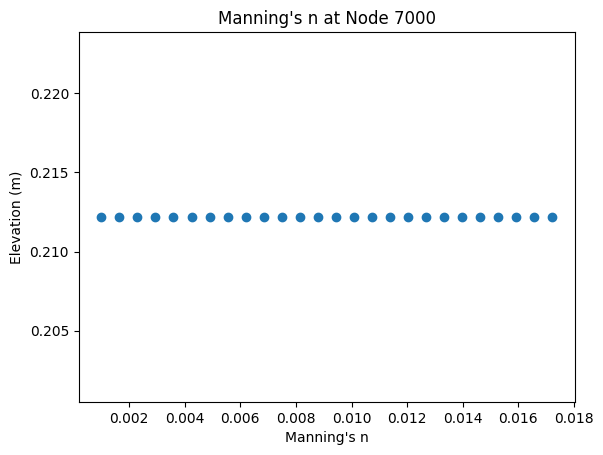

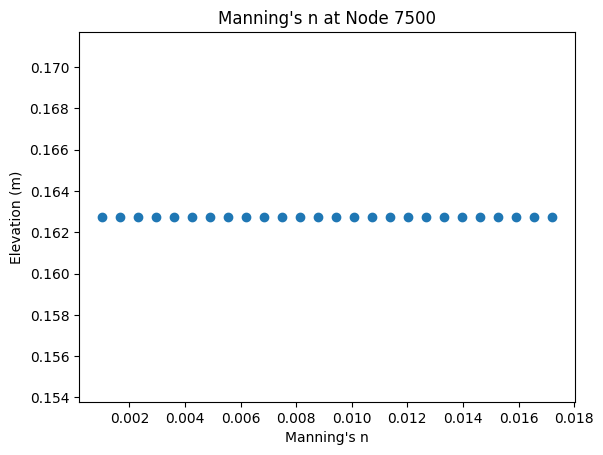

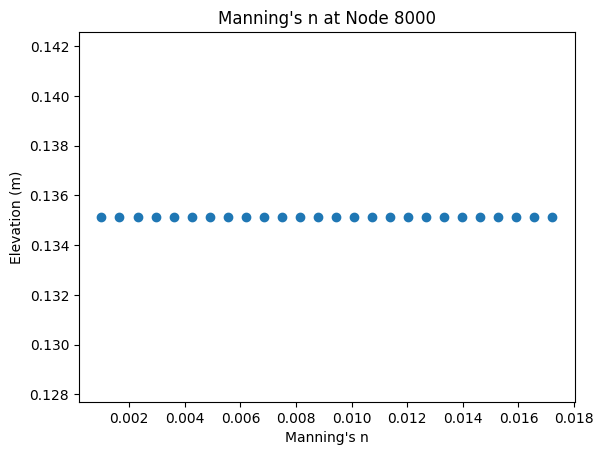

In [ ]:



for i in range(0, 8006, 500):
    # Picks a node location
    ele_at_node = mannings_n_samples.iloc[i] 
    # manning's n values that we computed
    n = np.linspace(0.001, 0.01722, 26)
    fig = plt.figure()
    plt.title('Manning\'s n at Node %i' % i)
    plt.scatter(n, ele_at_node)
    plt.xlabel('Manning\'s n')
    plt.ylabel('Elevation (m)')


Text(0.5, 1.0, 'Drag Coefficient vs. Elevation at Station 1')

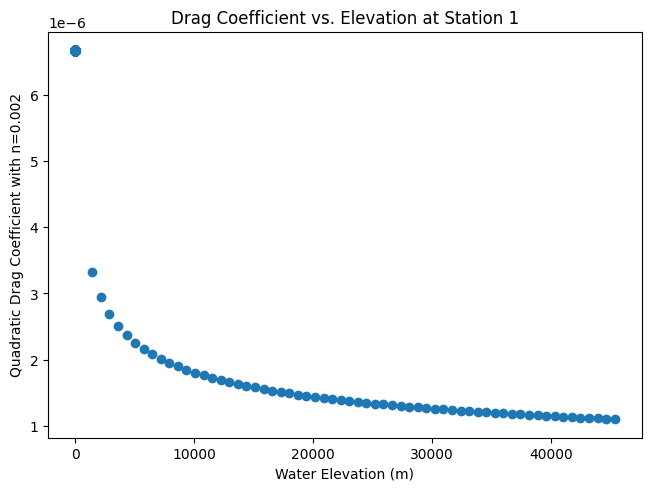

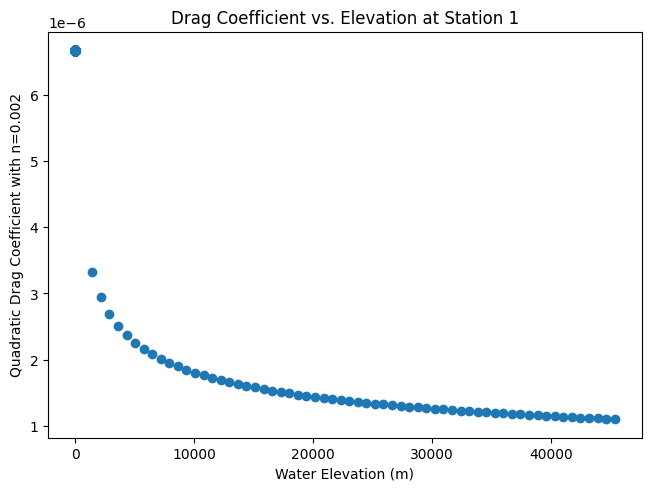

In [ ]:
# This is just hard-coding for one or two stations

with open(OUTPUT_DIRECTORY/"fort61.txt") as f:
    station1 = pd.DataFrame([line.strip().split() for line in f.readlines()],
                           columns=['TimePt', 'Ele'])
    
station1.loc[0:369, 'Ele']  # -96,27

with open(OUTPUT_DIRECTORY/"fort61.txt") as f:
    station25 = pd.DataFrame([line.strip().split() for line in f.readlines()],
                           columns=['TimePt', 'Ele'])
    
station25.loc[9276:9646, 'Ele']  

   
g = 9.8 # acceleration for gravity
n = 0.002 # manning's n coeff

h = mesh.loc[2554,'Depth'] # need location to match station 1
h = np.asarray(h, dtype=float)
h.astype(int)

eta1 = station1[['Ele']].to_numpy() # elevation at each time point
eta1 = np.asarray(eta1, dtype=float)
eta1.astype(int)

eta2 = station25[['Ele']].to_numpy() # elevation at each time point
eta2 = np.asarray(eta2, dtype=float)
eta2.astype(int)


fig, ax = plt.subplots(layout='constrained') 
numerator = g*np.square(n)
denom = np.cbrt(h + eta1)
Cd = numerator/denom
ax.scatter(eta1, Cd)
ax.set_xlabel("Water Elevation (m)")
ax.set_ylabel("Quadratic Drag Coefficient with n=0.002")
ax.set_title("Drag Coefficient vs. Elevation at Station 1")

fig, ax = plt.subplots(layout='constrained') 
numerator = g*np.square(n)
denom = np.cbrt(h + eta2)
Cd = numerator/denom
ax.scatter(eta2, Cd)
ax.set_xlabel("Water Elevation (m)")
ax.set_ylabel("Quadratic Drag Coefficient with n=0.002")
ax.set_title("Drag Coefficient vs. Elevation at Station 1")


In [ ]:
# Attempting to generalize the wind drag coeff. computation

stations = pd.read_csv(OUTPUT_DIRECTORY/"fort61.csv", header = None)

def Get_Drag_Coeff(n, nstae):
    # n is the Manning's n coefficient
    # h is the depth at the station
    # nstae is the chosen station number
    # eta is elevation at each time point
    g = 9.8

    h = mesh.loc[2554,'Depth'] 
    # need to find a better way to match depth to the station location, 
    # this is hard-coded to be Key West
    h = np.asarray(h, dtype=float)
    h.astype(int)
    
    eta = stations.loc[:,nstae-1]

    numerator = g*np.square(n) 
    denom = np.cbrt(h + eta)

    Cd = numerator/denom

    return Cd

   
Cd = Get_Drag_Coeff(0.002,25)

print(Cd)


# fig, ax = plt.subplots(layout='constrained') 
# ax.scatter(eta, Cd)
# ax.set_xlabel("Water Elevation (m)")
# ax.set_ylabel("Quadratic Drag Coefficient with n=0.002")
# ax.set_title("Drag Coefficient vs. Elevation at Station 1")

0     0.000007
1     0.000007
2     0.000007
3     0.000007
4     0.000007
        ...   
58    0.000007
59    0.000007
60    0.000007
61    0.000007
62    0.000007
Name: 24, Length: 63, dtype: float64
